# Python, Data Visualization, and Census Data

By: Dr. Eric Godat

## Session Goals

Today we will use Python to move from **data** to **questions** to
**evidence**.

By the end of this notebook, you should be able to:

- load and inspect tabular data
- create new columns from existing columns
- filter, sort, and summarize data
- make basic visualizations with pandas and matplotlib
- combine two datasets using a shared key
- begin asking questions with Census/ACS data

The big idea today is:

> Data science is not just about running code. It is about deciding what
> matters, testing assumptions, and interpreting patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Part 1: Finding the Best Apartment

Suppose you are trying to find the best apartment near campus.

Different apartments have different:

- rent
- size
- number of bedrooms
- number of bathrooms
- distance to campus
- rating
- pet rules

Before we write any code, discuss:

> What makes an apartment “good”?

There is no single correct answer. That is what makes this a useful data
science problem.

In [2]:
apartments = {
    "Apartment": [
        "Mockingbird Flats",
        "Highland House",
        "Campus View",
        "The Village",
        "Oak Lawn Lofts",
        "Greenville Commons",
        "Mustang Station",
        "The Hidden Gem"
    ],
    "Rent": [950, 1450, 1100, 1700, 2100, 1250, 800, 1350],
    "Bedrooms": [1, 2, 1, 3, 2, 2, 1, 2],
    "Bathrooms": [1, 2, 1, 2, 2, 1, 1, 2],
    "Sqft": [550, 980, 620, 1400, 1150, 870, 450, 760],
    "Distance": [0.4, 1.8, 0.2, 3.5, 2.2, 1.1, 0.1, 0.9],
    "Rating": [3.8, 4.6, 3.2, 4.9, 4.7, 4.1, 2.9, 4.8],
    "pets_allowed": [
        "cat only",
        "dog and cat",
        "no",
        "all pets",
        "dog and cat",
        "cat only",
        "no",
        "all pets"
    ]
}

apts = pd.DataFrame(apartments)
apts

,Apartment,Rent,Bedrooms,Bathrooms,Sqft,Distance,Rating,pets_allowed
0,Mockingbird Flats,950,1,1,550,0.4,3.8,cat only
1,Highland House,1450,2,2,980,1.8,4.6,dog and cat
2,Campus View,1100,1,1,620,0.2,3.2,no
3,The Village,1700,3,2,1400,3.5,4.9,all pets
4,Oak Lawn Lofts,2100,2,2,1150,2.2,4.7,dog and cat
5,Greenville Commons,1250,2,1,870,1.1,4.1,cat only
6,Mustang Station,800,1,1,450,0.1,2.9,no
7,The Hidden Gem,1350,2,2,760,0.9,4.8,all pets


## First Impressions

Before calculating anything:

> Which apartment looks best to you? Why?

This is an important first step. Humans often have strong intuitions
about data before doing formal analysis.

## Question 1: Which apartment is cheapest?

In [3]:
apts.sort_values(by="Rent")

,Apartment,Rent,Bedrooms,Bathrooms,Sqft,Distance,Rating,pets_allowed
6,Mustang Station,800,1,1,450,0.1,2.9,no
0,Mockingbird Flats,950,1,1,550,0.4,3.8,cat only
2,Campus View,1100,1,1,620,0.2,3.2,no
5,Greenville Commons,1250,2,1,870,1.1,4.1,cat only
7,The Hidden Gem,1350,2,2,760,0.9,4.8,all pets
1,Highland House,1450,2,2,980,1.8,4.6,dog and cat
3,The Village,1700,3,2,1400,3.5,4.9,all pets
4,Oak Lawn Lofts,2100,2,2,1150,2.2,4.7,dog and cat


## Question 2: Which apartment gives the most space per dollar?

In [4]:
apts["sqft_per_dollar"] = apts["Sqft"] / apts["Rent"]
apts[["Apartment", "Rent", "Sqft", "sqft_per_dollar"]].sort_values(
    by="sqft_per_dollar",
    ascending=False
)

,Apartment,Rent,Sqft,sqft_per_dollar
3,The Village,1700,1400,0.823529
5,Greenville Commons,1250,870,0.696000
1,Highland House,1450,980,0.675862
0,Mockingbird Flats,950,550,0.578947
2,Campus View,1100,620,0.563636
7,The Hidden Gem,1350,760,0.562963
6,Mustang Station,800,450,0.562500
4,Oak Lawn Lofts,2100,1150,0.547619


## Question 3: Which apartments meet a student’s basic needs?

Suppose a student wants:

- at least 2 bedrooms
- rent below \$1500

In [5]:
apts[(apts["Bedrooms"] >= 2) & (apts["Rent"] < 1500)]

,Apartment,Rent,Bedrooms,Bathrooms,Sqft,Distance,Rating,pets_allowed,sqft_per_dollar
1,Highland House,1450,2,2,980,1.8,4.6,dog and cat,0.675862
5,Greenville Commons,1250,2,1,870,1.1,4.1,cat only,0.696000
7,The Hidden Gem,1350,2,2,760,0.9,4.8,all pets,0.562963


## Building a Bad Model First

Let’s try to build a simple apartment score.

This first model rewards:

- more space per dollar
- higher rating

In [6]:
apts["simple_score"] = apts["sqft_per_dollar"] * apts["Rating"]

apts[["Apartment", "Rent", "Sqft", "Distance", "Rating", "pets_allowed", "simple_score"]].sort_values(
    by="simple_score",
    ascending=False
)

,Apartment,Rent,Sqft,Distance,Rating,pets_allowed,simple_score
3,The Village,1700,1400,3.5,4.9,all pets,4.035294
1,Highland House,1450,980,1.8,4.6,dog and cat,3.108966
5,Greenville Commons,1250,870,1.1,4.1,cat only,2.853600
7,The Hidden Gem,1350,760,0.9,4.8,all pets,2.702222
4,Oak Lawn Lofts,2100,1150,2.2,4.7,dog and cat,2.573810
0,Mockingbird Flats,950,550,0.4,3.8,cat only,2.200000
2,Campus View,1100,620,0.2,3.2,no,1.803636
6,Mustang Station,800,450,0.1,2.9,no,1.631250


## Discussion

Does this ranking feel right?

What is missing from the model?

Some possibilities:

- distance to campus
- pet policy
- parking
- safety
- noise
- roommates
- public transit
- laundry
- whether rent includes utilities

The model reflects the variables we choose to include.

## Improving the Model

Distance matters. Smaller distances should get better scores.

One simple way to reward closer apartments is to use:


1 / distance

In [7]:
apts["distance_score"] = 1 / apts["Distance"]

apts[["Apartment", "Distance", "distance_score"]].sort_values(
    by="distance_score",
    ascending=False
)

,Apartment,Distance,distance_score
6,Mustang Station,0.1,10.000000
2,Campus View,0.2,5.000000
0,Mockingbird Flats,0.4,2.500000
7,The Hidden Gem,0.9,1.111111
5,Greenville Commons,1.1,0.909091
1,Highland House,1.8,0.555556
4,Oak Lawn Lofts,2.2,0.454545
3,The Village,3.5,0.285714


Now combine value, rating, and distance.

In [8]:
apts["final_score"] = (
    apts["sqft_per_dollar"]
    * apts["Rating"]
    * apts["distance_score"]
)

In [9]:
apts[["Apartment", "Rent", "Sqft", "Distance", "Rating", "pets_allowed", "final_score"]].sort_values(
    by="final_score",
    ascending=False
)

,Apartment,Rent,Sqft,Distance,Rating,pets_allowed,final_score
6,Mustang Station,800,450,0.1,2.9,no,16.312500
2,Campus View,1100,620,0.2,3.2,no,9.018182
0,Mockingbird Flats,950,550,0.4,3.8,cat only,5.500000
7,The Hidden Gem,1350,760,0.9,4.8,all pets,3.002469
5,Greenville Commons,1250,870,1.1,4.1,cat only,2.594182
1,Highland House,1450,980,1.8,4.6,dog and cat,1.727203
4,Oak Lawn Lofts,2100,1150,2.2,4.7,dog and cat,1.169913
3,The Village,1700,1400,3.5,4.9,all pets,1.152941


## You Try

Modify the score.

Ideas:

- include number of bedrooms
- make rent matter more
- make distance matter less
- create a filter for apartments that allow pets
- remove apartments below a certain rating

In [10]:

# Your code here


## AI Assistant Checkpoint

Ask an AI assistant one of the following:

- “Explain how this apartment score works in plain English.”
- “What assumptions are built into this formula?”
- “How could I change the formula to care more about distance?”

Then decide whether the suggestion actually makes sense.

# Part 2: Visualizing the Apartment Data

A good visualization starts with a question.

Not:

> What plot can I make?

But:

> What question am I trying to answer?

## Question: How much does each apartment cost?

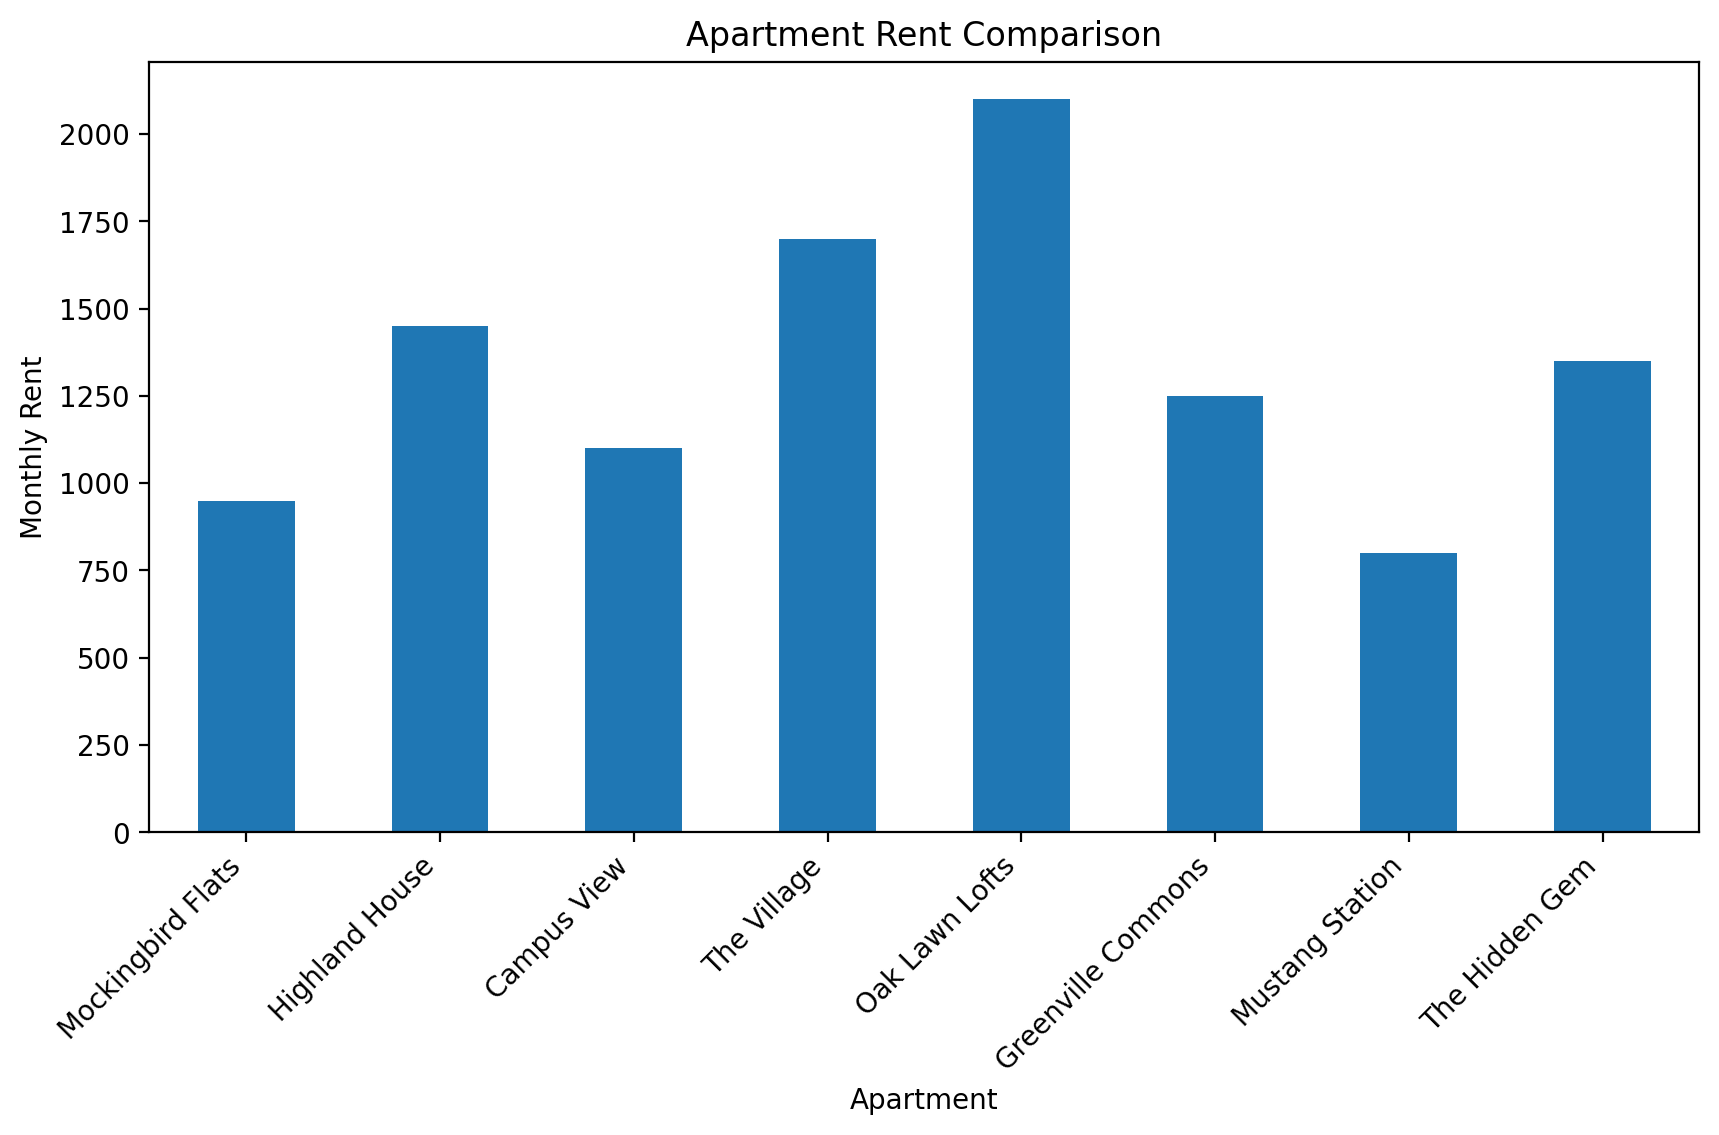

In [11]:
apts.plot.bar(x="Apartment", y="Rent", figsize=(10, 5), legend=False)
plt.ylabel("Monthly Rent")
plt.title("Apartment Rent Comparison")
plt.xticks(rotation=45, ha="right");

## Question: Are more expensive apartments rated better?

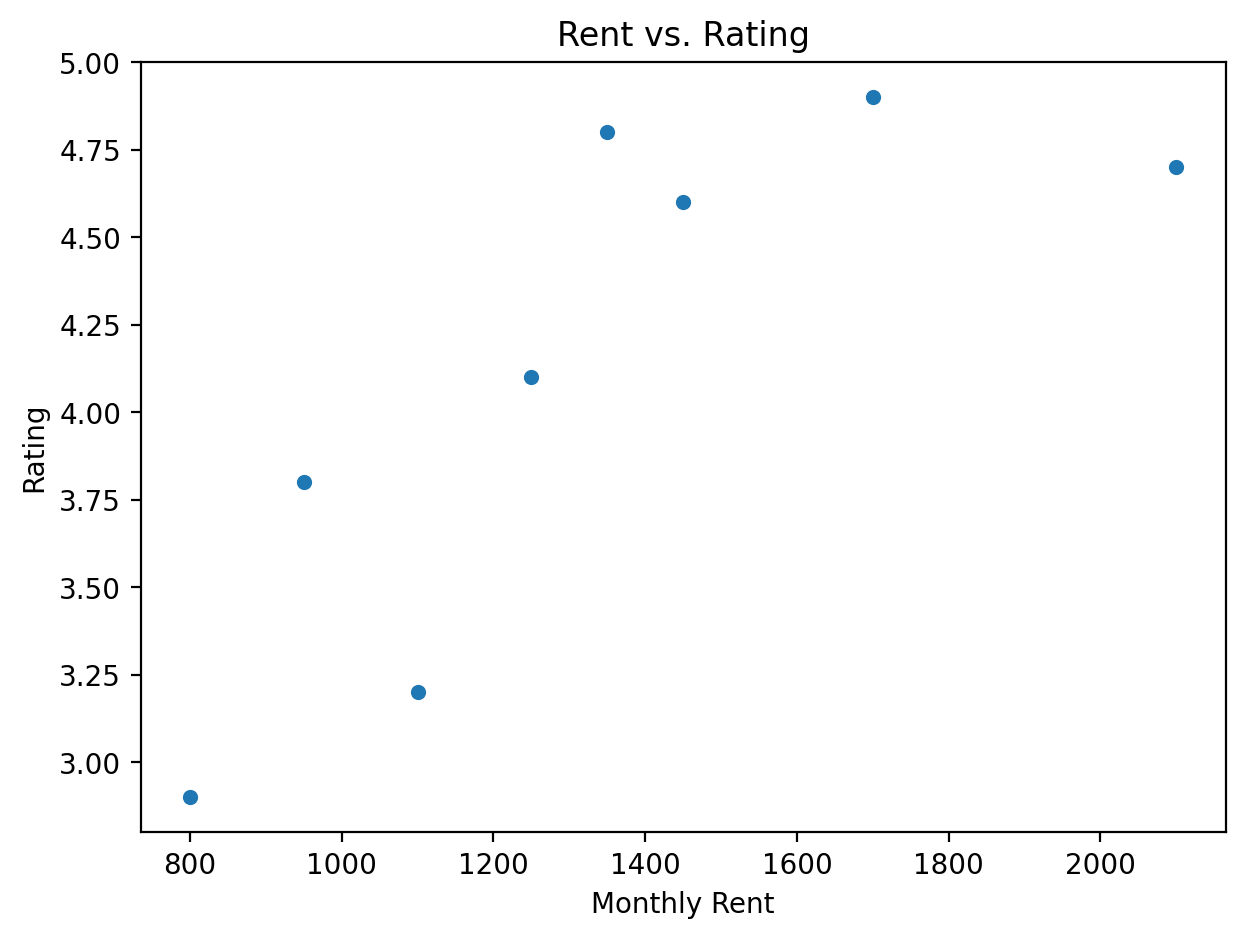

In [12]:
apts.plot.scatter(x="Rent", y="Rating", figsize=(7, 5))
plt.title("Rent vs. Rating")
plt.xlabel("Monthly Rent")
plt.ylabel("Rating");

## Question: How are final scores distributed?

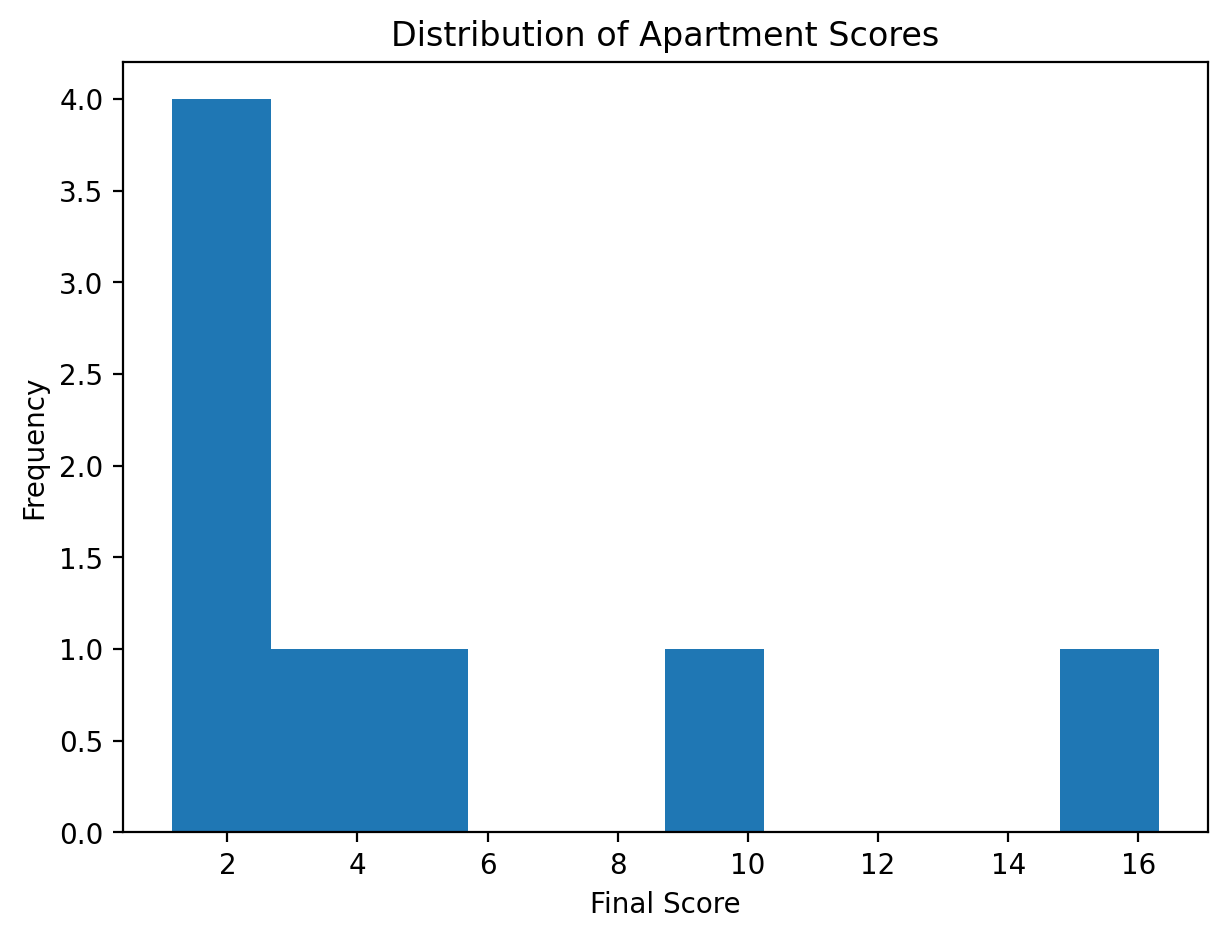

In [13]:
apts["final_score"].plot.hist(figsize=(7, 5))
plt.title("Distribution of Apartment Scores")
plt.xlabel("Final Score");

## Question: Which apartment wins under our model?

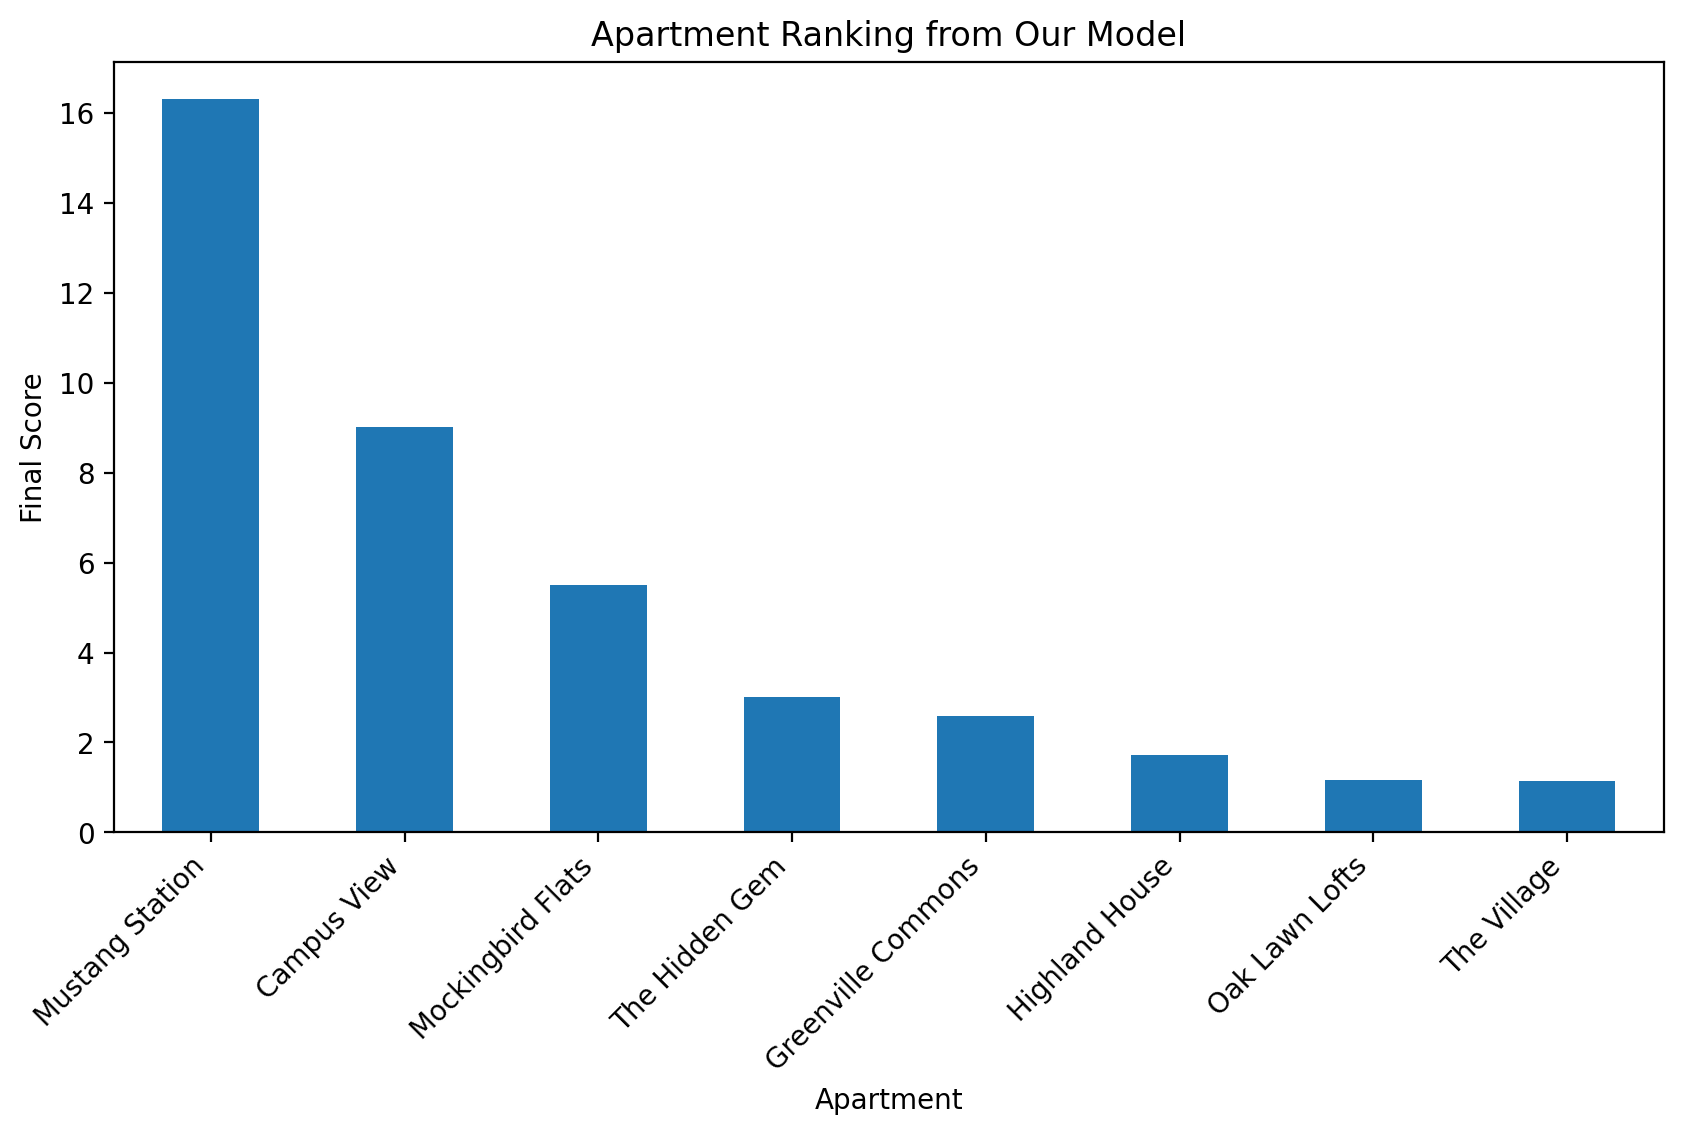

In [14]:
apts.sort_values(by="final_score", ascending=False).plot.bar(
    x="Apartment",
    y="final_score",
    figsize=(10, 5),
    legend=False
)
plt.ylabel("Final Score")
plt.title("Apartment Ranking from Our Model")
plt.xticks(rotation=45, ha="right");

## Visualization Reflection

For each plot, ask:

- What question does this plot answer?
- What does this plot hide?
- What choices did we make when creating it?
- Could a different plot tell a different story?

# Part 3: Moving to Public Data — Texas ACS/Census Sample

Now we will use the same basic pandas and plotting skills on real public
data.

This dataset is a prepared sample from the American Community Survey for
Texas counties.

We are using a prepared CSV so that we can focus on analysis rather than
API syntax.

In [19]:
acs = pd.read_csv("texas_ACS_2024_sample.csv")
acs.head()

,Unnamed: 0,geoid,name,Total Population,Population 16 years and over in labor force,Population 25 years and over with Bachelors Degree or higher,Population 16 and over with income in the past 12 months below poverty level,Households with Internet Subscription,Total Population in Renter Occupied Housing,Median Household Income in the Past 12 Months (In 2024 Inflation-adjusted Dollars),Total Population in Owner Occupied Housing
0,0,05000US48001,"Anderson County, TX",58439,22510,6511,5822,15509,13242,62068,34828
1,1,05000US48003,"Andrews County, TX",18610,8947,1991,2030,6116,3388,72242,15022
2,2,05000US48005,"Angelina County, TX",87275,39781,10322,9084,29340,27934,60960,55932
3,3,05000US48007,"Aransas County, TX",24876,10758,5602,2755,11209,5005,69466,19600
4,4,05000US48009,"Archer County, TX",8867,4263,1608,626,3069,1226,72159,7572


## Inspect the Data

In [20]:
acs.shape

(254, 11)

In [21]:
acs.columns

Index(['Unnamed: 0', 'geoid', 'name', 'Total Population',
       'Population 16 years and over in labor force',
       'Population 25 years and over with Bachelors Degree or higher',
       'Population 16 and over with income in the past 12 months below poverty level',
       'Households with Internet Subscription',
       'Total Population in Renter Occupied Housing',
       'Median Household Income in the Past 12 Months (In 2024 Inflation-adjusted Dollars)',
       'Total Population in Owner Occupied Housing'],
      dtype='object')

In [22]:
acs.head(3)

,Unnamed: 0,geoid,name,Total Population,Population 16 years and over in labor force,Population 25 years and over with Bachelors Degree or higher,Population 16 and over with income in the past 12 months below poverty level,Households with Internet Subscription,Total Population in Renter Occupied Housing,Median Household Income in the Past 12 Months (In 2024 Inflation-adjusted Dollars),Total Population in Owner Occupied Housing
0,0,05000US48001,"Anderson County, TX",58439,22510,6511,5822,15509,13242,62068,34828
1,1,05000US48003,"Andrews County, TX",18610,8947,1991,2030,6116,3388,72242,15022
2,2,05000US48005,"Angelina County, TX",87275,39781,10322,9084,29340,27934,60960,55932


## Clean Up Column Names

Real datasets often have long or awkward column names. It is common to
rename columns before analysis.

In [23]:
acs = acs.rename(columns={
    "geoid": "geoid",
    "name": "county",
    "Total Population": "population",
    "Population 16 years and over in labor force": "labor_force",
    "Population 25 years and over with Bachelors Degree or higher": "bachelors_degree",
    "Population 16 and over with income in the past 12 months below poverty level": "poverty_population",
    "Households with Internet Subscription": "internet_households",
    "Total Population in Renter Occupied Housing": "renters",
    "Median Household Income in the Past 12 Months (In 2024 Inflation-adjusted Dollars)": "median_income",
    "Total Population in Owner Occupied Housing": "owners"
})

acs = acs.drop(columns=["Unnamed: 0"], errors="ignore")
acs.head()

,geoid,county,population,labor_force,bachelors_degree,poverty_population,internet_households,renters,median_income,owners
0,05000US48001,"Anderson County, TX",58439,22510,6511,5822,15509,13242,62068,34828
1,05000US48003,"Andrews County, TX",18610,8947,1991,2030,6116,3388,72242,15022
2,05000US48005,"Angelina County, TX",87275,39781,10322,9084,29340,27934,60960,55932
3,05000US48007,"Aransas County, TX",24876,10758,5602,2755,11209,5005,69466,19600
4,05000US48009,"Archer County, TX",8867,4263,1608,626,3069,1226,72159,7572


## Create a Short County Name

The county names currently look like `Dallas County, TX`. For some joins
and labels, it is useful to make a shorter county name.

In [24]:
acs["county_name"] = acs["county"].str.replace(" County, TX", "", regex=False)
acs[["county", "county_name"]].head()

,county,county_name
0,"Anderson County, TX",Anderson
1,"Andrews County, TX",Andrews
2,"Angelina County, TX",Angelina
3,"Aransas County, TX",Aransas
4,"Archer County, TX",Archer


# Part 4: Totals Can Mislead

A common beginner mistake is to compare raw totals without accounting
for population size.

Big counties often dominate totals simply because they have more people.

## Which counties have the largest population?

In [25]:
acs[["county", "population"]].sort_values(by="population", ascending=False).head(10)

,county,population
100,"Harris County, TX",4838303
56,"Dallas County, TX",2621179
219,"Tarrant County, TX",2167390
14,"Bexar County, TX",2067341
226,"Travis County, TX",1330015
42,"Collin County, TX",1163337
60,"Denton County, TX",979561
78,"Fort Bend County, TX",893767
107,"Hidalgo County, TX",891977
70,"El Paso County, TX",870779


## Which counties have the most people with bachelor’s degrees?

In [26]:
acs[["county", "population", "bachelors_degree"]].sort_values(
    by="bachelors_degree",
    ascending=False
).head(10)

,county,population,bachelors_degree
100,"Harris County, TX",4838303,1072128
56,"Dallas County, TX",2621179,610863
226,"Travis County, TX",1330015,532790
219,"Tarrant County, TX",2167390,491238
42,"Collin County, TX",1163337,435736
14,"Bexar County, TX",2067341,429670
60,"Denton County, TX",979561,327798
78,"Fort Bend County, TX",893767,291844
245,"Williamson County, TX",672688,221859
169,"Montgomery County, TX",684432,174561


Is this surprising?

Or are we mostly seeing the biggest counties again?

## Create Rates and Percentages

Rates often make comparisons more meaningful.

In [27]:
acs["bachelors_rate"] = acs["bachelors_degree"] / acs["population"]
acs["poverty_rate"] = acs["poverty_population"] / acs["labor_force"]
acs["renter_rate"] = acs["renters"] / (acs["renters"] + acs["owners"])
acs["internet_rate"] = acs["internet_households"] / (acs["renters"] + acs["owners"])

In [28]:
acs[[
    "county",
    "population",
    "median_income",
    "bachelors_rate",
    "poverty_rate",
    "renter_rate",
    "internet_rate"
]].head()

,county,population,median_income,bachelors_rate,poverty_rate,renter_rate,internet_rate
0,"Anderson County, TX",58439,62068,0.111415,0.258641,0.275473,0.322634
1,"Andrews County, TX",18610,72242,0.106985,0.226892,0.184030,0.332211
2,"Angelina County, TX",87275,60960,0.118270,0.228350,0.333079,0.349844
3,"Aransas County, TX",24876,69466,0.225197,0.256088,0.203414,0.455558
4,"Archer County, TX",8867,72159,0.181347,0.146845,0.139350,0.348829


## Which counties have the highest bachelor’s degree rate?

In [29]:
acs[["county", "population", "bachelors_rate"]].sort_values(
    by="bachelors_rate",
    ascending=False
).head(10)

,county,population,bachelors_rate
226,"Travis County, TX",1330015,0.400589
42,"Collin County, TX",1163337,0.374557
21,"Brewster County, TX",9503,0.345154
129,"Kendall County, TX",48567,0.342599
60,"Denton County, TX",979561,0.334638
134,"King County, TX",211,0.331754
245,"Williamson County, TX",672688,0.329810
78,"Fort Bend County, TX",893767,0.326533
45,"Comal County, TX",183826,0.305800
121,"Jeff Davis County, TX",1865,0.294370


## Which counties have the highest poverty rate?

In [30]:
acs[["county", "population", "poverty_rate"]].sort_values(
    by="poverty_rate",
    ascending=False
).head(10)

,county,population,poverty_rate
63,"Dimmit County, TX",8380,0.782025
252,"Zapata County, TX",13841,0.598715
192,"Real County, TX",2802,0.591724
213,"Starr County, TX",66067,0.525818
253,"Zavala County, TX",9412,0.501917
134,"King County, TX",211,0.500000
65,"Duval County, TX",9742,0.495366
121,"Jeff Davis County, TX",1865,0.486310
202,"San Augustine County, TX",7874,0.476147
218,"Swisher County, TX",6937,0.470914


## Discussion

How did the rankings change when we moved from totals to rates?

Why does that matter?

# Part 5: Visualizing ACS Relationships

## Question: Is education related to income?

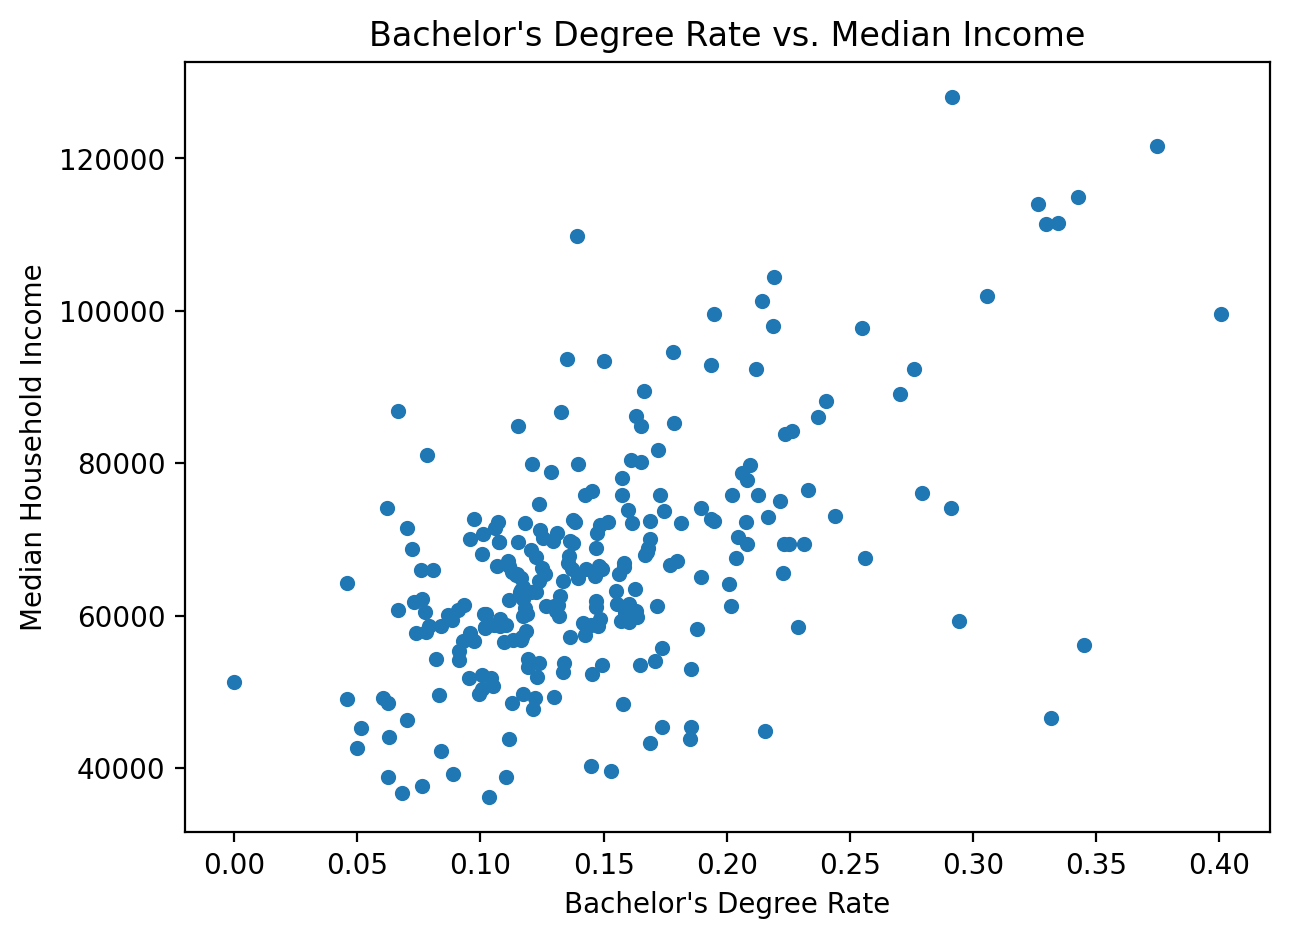

In [31]:
acs.plot.scatter(
    x="bachelors_rate",
    y="median_income",
    figsize=(7, 5)
)
plt.title("Bachelor's Degree Rate vs. Median Income")
plt.xlabel("Bachelor's Degree Rate")
plt.ylabel("Median Household Income");

## Question: Is poverty related to internet access?

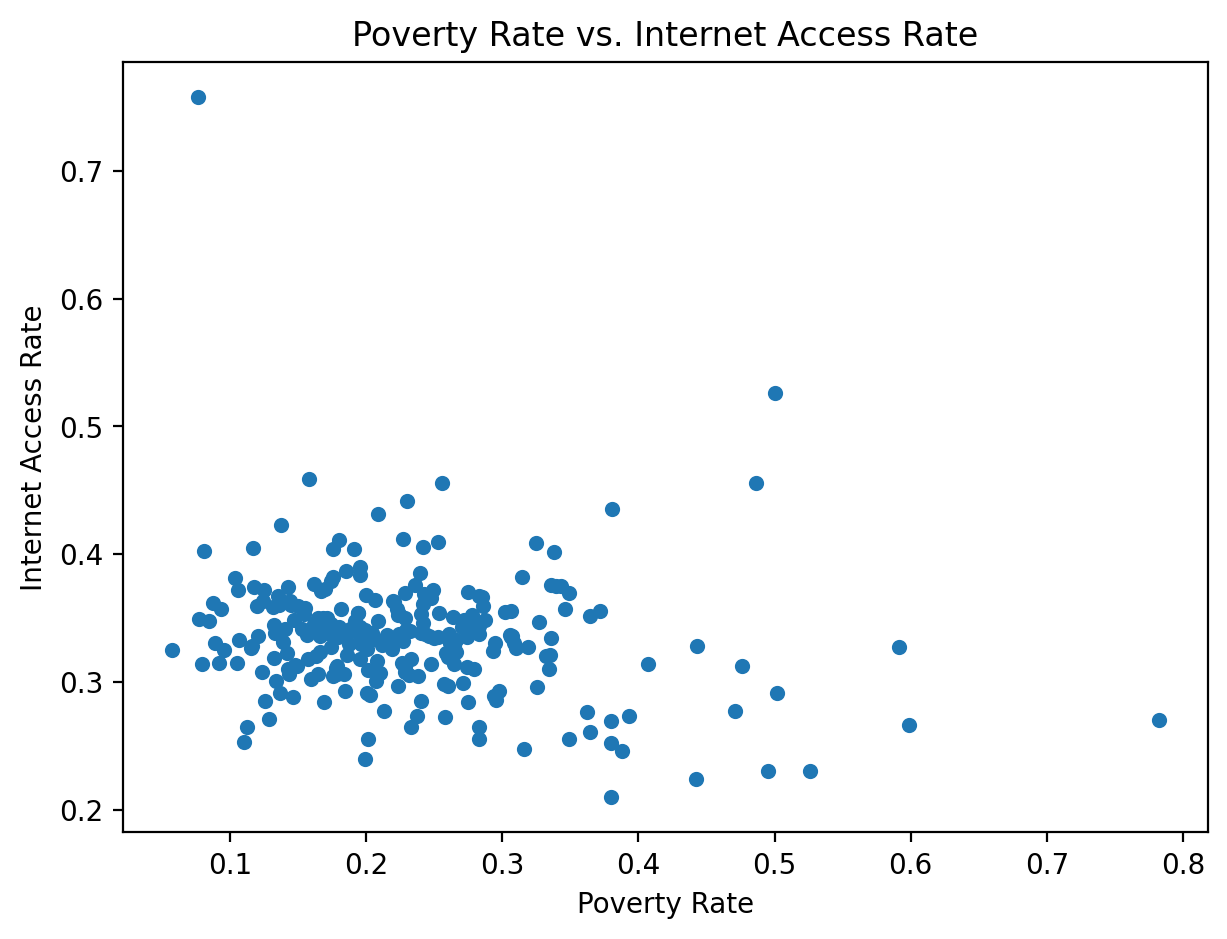

In [32]:
acs.plot.scatter(
    x="poverty_rate",
    y="internet_rate",
    figsize=(7, 5)
)
plt.title("Poverty Rate vs. Internet Access Rate")
plt.xlabel("Poverty Rate")
plt.ylabel("Internet Access Rate");

## Question: Are renter-heavy counties different?

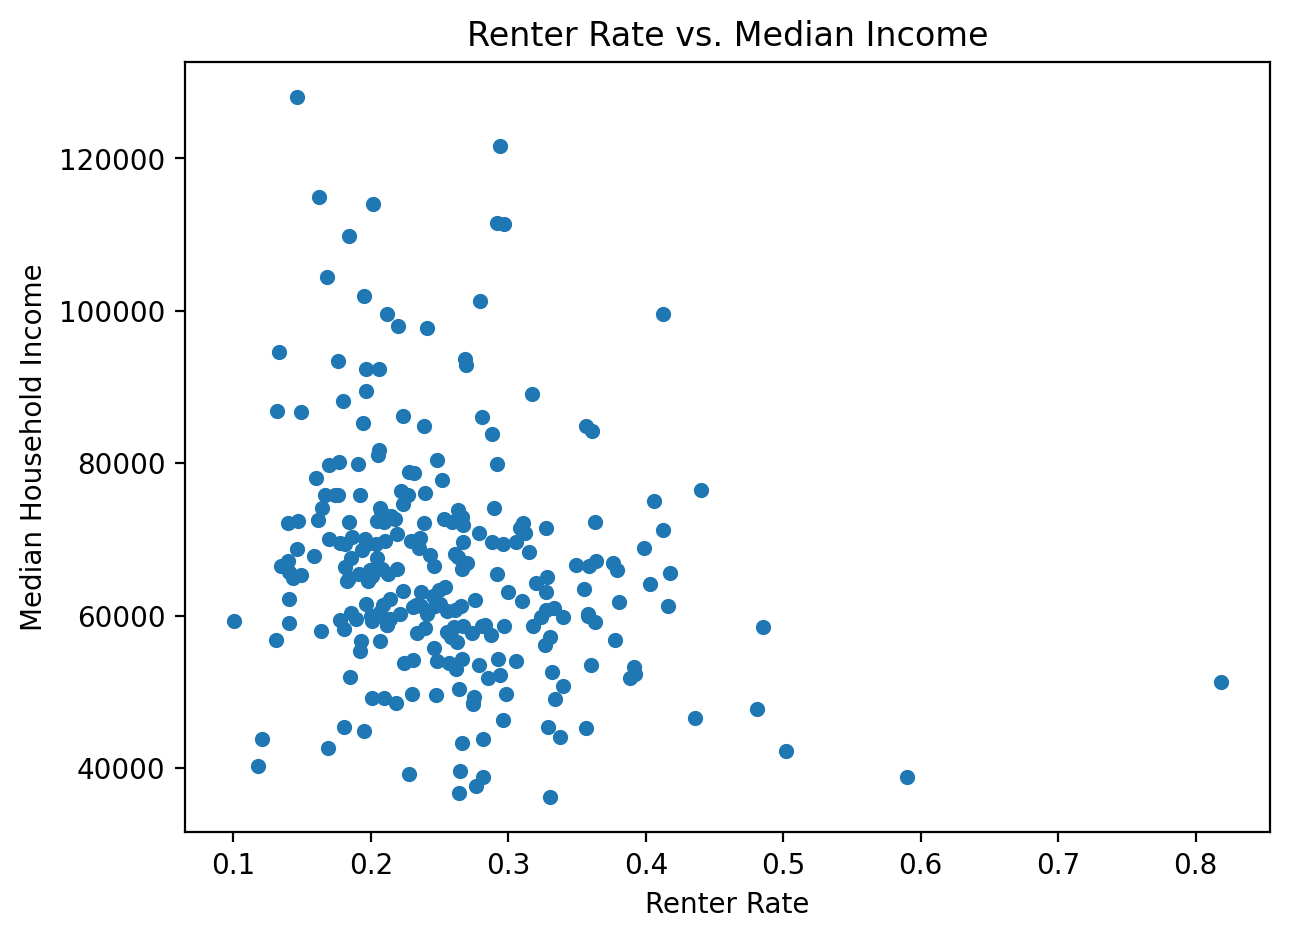

In [33]:
acs.plot.scatter(
    x="renter_rate",
    y="median_income",
    figsize=(7, 5)
)
plt.title("Renter Rate vs. Median Income")
plt.xlabel("Renter Rate")
plt.ylabel("Median Household Income");

## You Try

Choose two variables and make a scatterplot.

Possible columns:

- population
- median_income
- bachelors_rate
- poverty_rate
- renter_rate
- internet_rate

In [34]:

# Your code here


## Finding Outliers

Scatterplots help us see patterns, but sometimes we want to inspect
specific rows.

Let’s look at counties with high income but lower bachelor’s degree
rates.

In [35]:
acs[(acs["median_income"] > 80000) & (acs["bachelors_rate"] < 0.20)][[
    "county", "population", "median_income", "bachelors_rate"
]].sort_values(by="median_income", ascending=False)

,county,population,median_income,bachelors_rate
35,"Chambers County, TX",51498,109804,0.139073
69,"Ellis County, TX",213160,99595,0.194905
246,"Wilson County, TX",52781,94565,0.178132
158,"Martin County, TX",5218,93734,0.135301
248,"Wise County, TX",75005,93421,0.150190
164,"Midland County, TX",174801,92874,0.193592
128,"Kaufman County, TX",172604,89485,0.166543
247,"Winkler County, TX",7454,86900,0.066541
206,"Schleicher County, TX",2381,86694,0.132717
10,"Bastrop County, TX",106582,86226,0.163217


## Discussion

What might explain outliers?

Possible answers:

- industry mix
- rural/urban differences
- oil and gas economies
- military bases
- small population effects
- measurement issues

This is where data analysis becomes interpretation.

# Part 6: Adding a Dataset — Texas State Parks by County

Now we will bring in a second dataset.

This is useful because real projects often require combining information
from multiple sources.

In [36]:
parks = pd.read_csv("texas_state_parks_by_county.csv")
parks.head()

,geoid,county_name,state_park_count
0,05000US48007,Aransas,1
1,05000US48015,Austin,1
2,05000US48019,Bandera,3
3,05000US48021,Bastrop,2
4,05000US48029,Bexar,1


## Inspect the Parks Data

In [37]:
parks.shape

(87, 3)

In [38]:
parks.columns

Index(['geoid', 'county_name', 'state_park_count'], dtype='object')

## Merge ACS and Parks Data

Both datasets include a `geoid` column. That gives us a shared key for
merging.

In [39]:
merged = pd.merge(
    acs,
    parks[["geoid", "state_park_count"]],
    on="geoid",
    how="left"
)

In [40]:
merged[["county", "population", "median_income", "state_park_count"]].head()

,county,population,median_income,state_park_count
0,"Anderson County, TX",58439,62068,NaN
1,"Andrews County, TX",18610,72242,NaN
2,"Angelina County, TX",87275,60960,NaN
3,"Aransas County, TX",24876,69466,1.0
4,"Archer County, TX",8867,72159,NaN


Some counties do not have a state park. Those counties will show up with
missing values.

For this exercise, we will replace missing park counts with 0.

In [41]:
merged["state_park_count"] = merged["state_park_count"].fillna(0)

In [42]:
merged[["county", "population", "median_income", "state_park_count"]].sort_values(
    by="state_park_count",
    ascending=False
).head(15)

,county,population,median_income,state_park_count
26,"Burnet County, TX",52652,78732,4.0
9,"Bandera County, TX",22021,75813,3.0
188,"Presidio County, TX",5930,43802,3.0
129,"Kendall County, TX",48567,114962,3.0
15,"Blanco County, TX",12446,92425,2.0
21,"Brewster County, TX",9503,56212,2.0
107,"Hidalgo County, TX",891977,54338,2.0
90,"Grayson County, TX",143337,72182,2.0
70,"El Paso County, TX",870779,59806,2.0
68,"Edwards County, TX",1290,40313,2.0


## Create Parks Per Person

Raw park counts can be misleading. A county with 1 park and 5,000 people
is different from a county with 1 park and 5 million people.

In [43]:
merged["parks_per_100k"] = merged["state_park_count"] / merged["population"] * 100000

In [44]:
merged[["county", "population", "state_park_count", "parks_per_100k"]].sort_values(
    by="parks_per_100k",
    ascending=False
).head(15)

,county,population,state_park_count,parks_per_100k
68,"Edwards County, TX",1290,2.0,155.038760
155,"McMullen County, TX",700,1.0,142.857143
22,"Briscoe County, TX",1301,1.0,76.863951
188,"Presidio County, TX",5930,3.0,50.590219
192,"Real County, TX",2802,1.0,35.688794
135,"Kinney County, TX",3157,1.0,31.675641
98,"Hardeman County, TX",3501,1.0,28.563268
133,"Kimble County, TX",4389,1.0,22.784233
51,"Crane County, TX",4610,1.0,21.691974
21,"Brewster County, TX",9503,2.0,21.045985


## Question: Do counties with more parks have higher income?

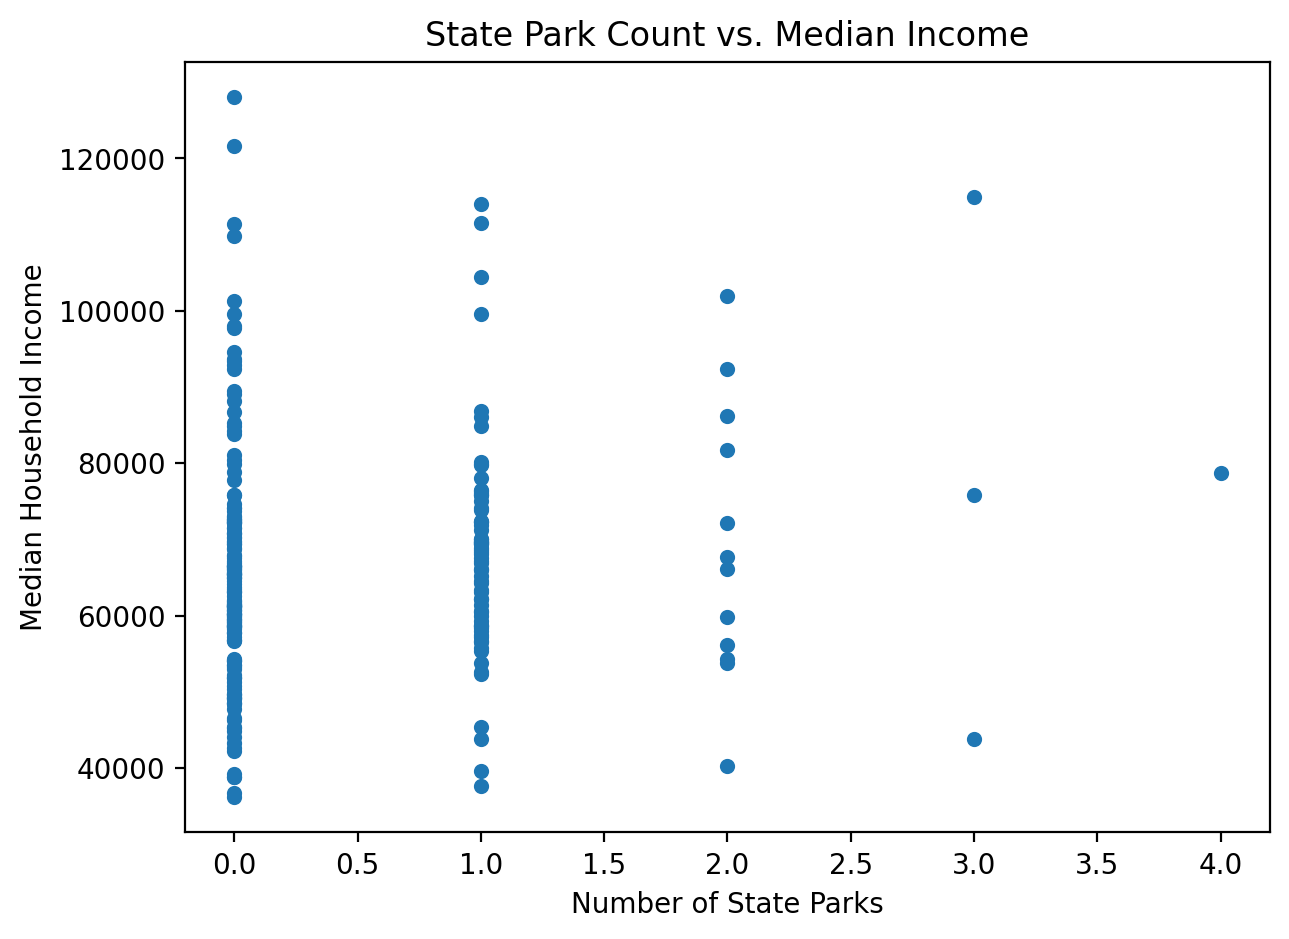

In [45]:
merged.plot.scatter(
    x="state_park_count",
    y="median_income",
    figsize=(7, 5)
)
plt.title("State Park Count vs. Median Income")
plt.xlabel("Number of State Parks")
plt.ylabel("Median Household Income");

## Question: Do counties with more parks per person have different poverty rates?

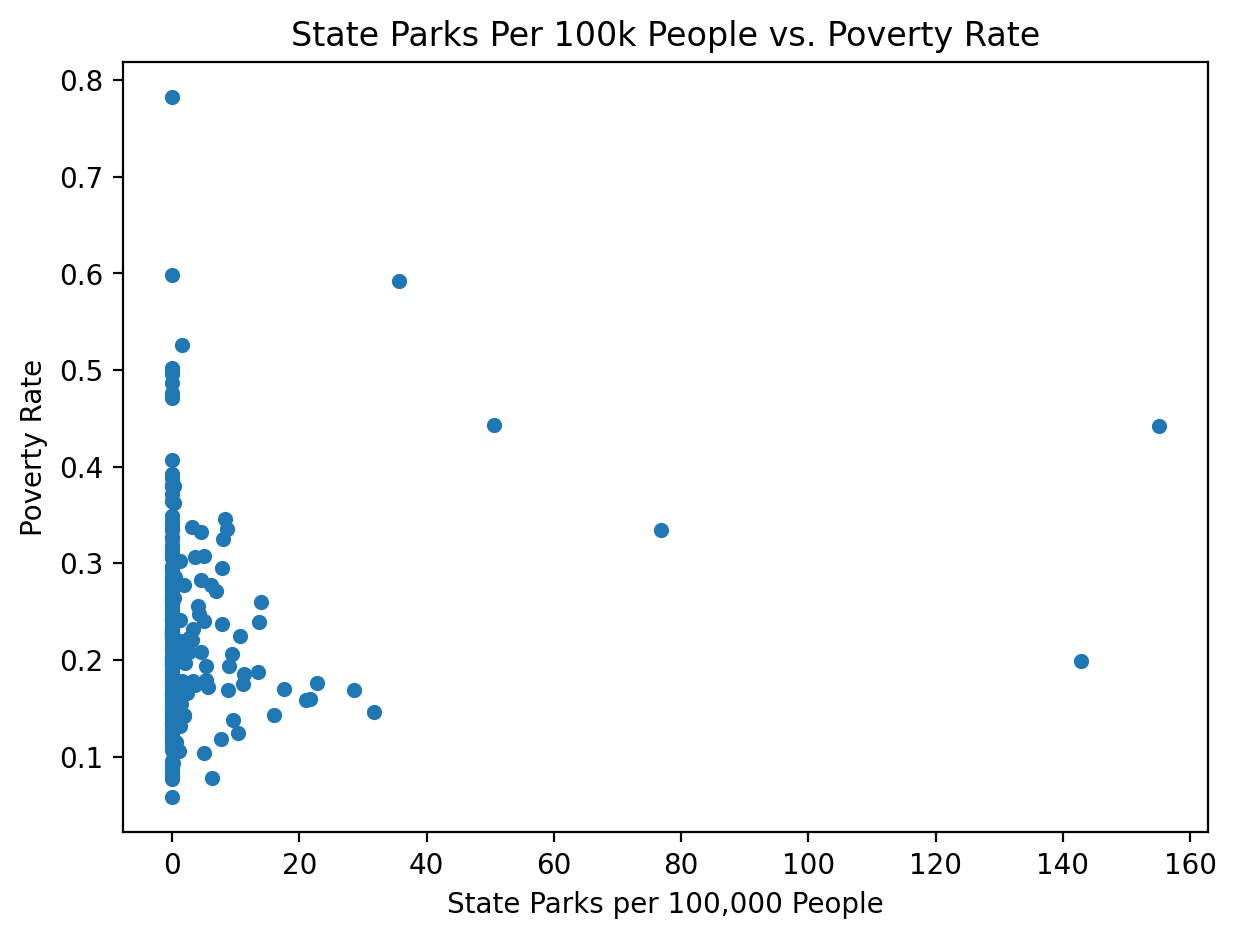

In [46]:
merged.plot.scatter(
    x="parks_per_100k",
    y="poverty_rate",
    figsize=(7, 5)
)
plt.title("State Parks Per 100k People vs. Poverty Rate")
plt.xlabel("State Parks per 100,000 People")
plt.ylabel("Poverty Rate");

## Discussion

State parks are a useful curveball variable.

They might relate to:

- geography
- tourism
- rural land use
- public investment
- quality of life
- population density

But they might not directly explain income, poverty, or internet access.

This is a good reminder:

> Interesting correlations are not automatically meaningful
> explanations.

# Part 7: Final Mini-Challenge

Choose one question to investigate.

## Option A: Apartment Model

Modify the apartment score and explain why your version is better.

## Option B: ACS Exploration

Find two ACS variables that seem related. Make a plot and describe the
pattern.

## Option C: Parks Curveball

Explore whether state parks appear related to income, poverty, internet
access, or population.

## Option D: Outlier Hunt

Find one county that surprises you and explain why.

In [47]:

# Your code here


# AI Assistant Checkpoint

Ask an AI assistant one of the following:

- “What are three possible explanations for this pattern?”
- “What might be misleading about this plot?”
- “How could I normalize this variable?”
- “What other data would I need to answer this question better?”

Then evaluate the answer. AI can help generate ideas, but you are
responsible for deciding whether those ideas make sense.

# Wrap-Up

Today we practiced:

- loading data
- creating new columns
- filtering and sorting
- building simple scoring models
- making plots
- comparing totals and rates
- merging datasets
- interpreting patterns carefully

The most important lesson is:

> Data science is not just computation. It is interpretation.

In the next session, we will extend these ideas by adding geography and
mapping.